In [73]:
import pandas as pd
import numpy as np
train = pd.read_csv('../data/train_eda_revised.csv')
test = pd.read_csv('../data/test_eda_revised.csv')

In [74]:
# seed 고정
import random, numpy as np, os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f"Seed {SEED} 고정 완료")

Seed 42 고정 완료


In [75]:
# due_weekend_flag별 target 비율
result = (
    train
    .groupby("due_weekend_flag")["target"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("비율(%)")
    .reset_index()
)
print(result)


   due_weekend_flag  target      비율(%)
0                 0       0  93.219386
1                 0       1   6.780614
2                 1       0  93.667042
3                 1       1   6.332958


In [76]:
# business code 별 target 비율
result = (
    train
    .groupby("business_code")["target"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("비율(%)")
    .reset_index()
)
print(result)

   business_code  target      비율(%)
0           CA02       0  80.250293
1           CA02       1  19.749707
2           U001       0  94.934607
3           U001       1   5.065393
4           U002       0  84.761905
5           U002       1  15.238095
6           U005       1  66.666667
7           U005       0  33.333333
8           U007       0  50.000000
9           U007       1  50.000000
10          U013       0  67.612293
11          U013       1  32.387707


In [77]:
train.iloc[1:6, 1:20].head(5)

,cust_number,name_customer,clear_date,buisness_year,due_in_date,posting_id,baseline_create_date,cust_payment_terms,target_old,amount_in_usd,cust_payment_terms_grp,baseline_month,baseline_day,baseline_dayofweek,Allowed_Pay_Days,business_days_late,target,due_weekend_flag,amount_bin
1,0140104249,SOB associates,2019-01-23,2019.0,2018-12-24,1.0,2018-12-14,CA10,1,11.663576,CA10,12,14,4,10,22,1,0,3
2,0200769623,WAL-MAR systems,2019-01-09,2019.0,2019-01-14,1.0,2018-12-30,NAH4,0,8.197049,NAH4,12,30,6,15,-3,0,0,0
3,0200769623,WAL-MAR foundation,2019-01-09,2019.0,2019-01-14,1.0,2018-12-30,NAH4,0,9.428658,NAH4,12,30,6,15,-3,0,0,1
4,0200792734,MDV/ corp,2019-01-14,2019.0,2019-01-14,1.0,2018-12-30,NAA8,0,11.457984,NAA8,12,30,6,15,0,0,0,3
5,0200769623,WAL-MAR in,2019-01-11,2019.0,2019-01-14,1.0,2018-12-30,NAH4,0,10.684894,NAH4,12,30,6,15,-1,0,0,2


In [78]:
drop_cols = ['cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date', 'posting_id',
             'baseline_create_date', 'target_old', 'due_in_date', 'year_month', 'business_days_late']

In [79]:
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [80]:
# 연체일을 나타내는 delay_days 피처 생성
# 타겟변수가 존재하기에 주석처리
"""
train['clear_date'] = pd.to_datetime(train['clear_date'])
train['due_in_date'] = pd.to_datetime(train['due_in_date'])
train['delay_days'] = (train['clear_date'] - train['due_in_date']).dt.days

test['clear_date'] = pd.to_datetime(test['clear_date'])
test['due_in_date'] = pd.to_datetime(test['due_in_date'])
test['delay_days'] = (test['clear_date'] - test['due_in_date']).dt.days

"""

"\ntrain['clear_date'] = pd.to_datetime(train['clear_date'])\ntrain['due_in_date'] = pd.to_datetime(train['due_in_date'])\ntrain['delay_days'] = (train['clear_date'] - train['due_in_date']).dt.days\n\ntest['clear_date'] = pd.to_datetime(test['clear_date'])\ntest['due_in_date'] = pd.to_datetime(test['due_in_date'])\ntest['delay_days'] = (test['clear_date'] - test['due_in_date']).dt.days\n\n"

In [81]:
#이진 분류 먼저 검증하기 위해 주석처리

"""
bins = [-float('inf'), 0, 5, 15, float('inf')]
labels = ['on_time_or_early', '1_5', '6_15', '16_plus']

# 4개의 클래스로 타깃 피처 생성(정상, 1-5일 지연, 6-15일 지연, 16이상 지연)
train['delay_class'] = pd.cut(train['delay_days'], bins=bins, labels=labels)
train['delay_class'].value_counts(dropna=False)
train['delay_class'].value_counts(normalize=True, dropna=False) * 100

test['delay_class'] = pd.cut(test['delay_days'], bins=bins, labels=labels)
test['delay_class'].value_counts(dropna=False)
test['delay_class'].value_counts(normalize=True, dropna=False) * 100
"""

"\nbins = [-float('inf'), 0, 5, 15, float('inf')]\nlabels = ['on_time_or_early', '1_5', '6_15', '16_plus']\n\n# 4개의 클래스로 타깃 피처 생성(정상, 1-5일 지연, 6-15일 지연, 16이상 지연)\ntrain['delay_class'] = pd.cut(train['delay_days'], bins=bins, labels=labels)\ntrain['delay_class'].value_counts(dropna=False)\ntrain['delay_class'].value_counts(normalize=True, dropna=False) * 100\n\ntest['delay_class'] = pd.cut(test['delay_days'], bins=bins, labels=labels)\ntest['delay_class'].value_counts(dropna=False)\ntest['delay_class'].value_counts(normalize=True, dropna=False) * 100\n"

In [82]:
train = train.dropna().copy()
test = test.dropna().copy()

In [83]:
from sklearn.preprocessing import OneHotEncoder
# 타깃 피처 분리
train_y = train['target'].copy()
train_x = train.drop(columns='target', axis=1)
test_y = test['target'].copy()
test_x = test.drop(columns='target', axis=1)

#원핫 인코딩
cat_cols = train_x.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = train_x.select_dtypes(exclude=['object', 'category']).columns.tolist()
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
train_cat = ohe.fit_transform(train_x[cat_cols])
test_cat = ohe.transform(test_x[cat_cols])

train_cat_df = pd.DataFrame(
    train_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=train_x.index
)

test_cat_df = pd.DataFrame(
    test_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=test_x.index
)

train_x = pd.concat([train_x[num_cols], train_cat_df], axis=1)
test_x = pd.concat([test_x[num_cols], test_cat_df], axis=1)


In [116]:
train.columns

Index(['business_code', 'cust_payment_terms', 'amount_in_usd',
       'cust_payment_terms_grp', 'baseline_month', 'baseline_day',
       'baseline_dayofweek', 'Allowed_Pay_Days', 'target', 'due_weekend_flag',
       'amount_bin', 'cust_allowed_pay_days_late_rate_past',
       'ratio_paid_invoices_late_past', 'avg_days_late_paid_late_past',
       'sum_outstanding_amount_past', 'recent_5_late_rate',
       'recent_10_late_rate', 'recent_20_late_rate',
       'late_rate_time_decay_lambda_0_8', 'current_transaction_count',
       'cleared_count', 'is_new_customer', 'is_last_late',
       'recent_3_late_rate', 'vix', 'hy_spread_proxy', 'vix_lag1', 'vix_lag2',
       'vix_lag3', 'hy_spread_proxy_lag1', 'hy_spread_proxy_lag2',
       'hy_spread_proxy_lag3', 'year_quarter', 'gdp_growth', 'unemployment',
       'cpi_yoy', 'fed_rate', 'wti_oil', 'dxy', 'retail_sales', 'fed_rate_chg',
       'gdp_growth_chg', 'unemployment_chg', 'cpi_yoy_chg', 'wti_oil_chg',
       'dxy_chg', 'retail_sales_chg']

In [115]:
len(train_x.columns), len(train.columns)

(150, 47)

In [87]:
#단일 모델로 로지스틱 회귀 사용
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
lr = LogisticRegression(
    max_iter=5000,
    random_state=42,
    class_weight='balanced'
)

lr.fit(train_x, train_y)
pred = lr.predict(test_x)

In [88]:
labels = train_y.unique()
print('accuracy:', accuracy_score(test_y, pred))
print('-------------')
print('macro f1:', f1_score(test_y, pred, average='macro'))
print('-------------')

accuracy: 0.834125
-------------
macro f1: 0.6024647634030619
-------------


In [117]:
import pandas as pd
import numpy as np

# 회귀 계수 추출
coef_df = pd.DataFrame({
    'feature'    : train_x.columns,
    'coefficient': lr.coef_[0],          # lr.coef_ shape: (1, n_features)
    'odds_ratio' : np.exp(lr.coef_[0])   # 오즈비 = e^계수
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

                             feature  coefficient  odds_ratio
     late_rate_time_decay_lambda_0_8     0.298320    1.347593
       ratio_paid_invoices_late_past     0.296402    1.345011
                 recent_20_late_rate     0.275486    1.317170
cust_allowed_pay_days_late_rate_past     0.274762    1.316217
                  recent_5_late_rate     0.271332    1.311711
                 recent_10_late_rate     0.266293    1.305117
         cust_payment_terms_grp_NAA8    -0.246742    0.781342
             cust_payment_terms_NAA8    -0.246742    0.781342
                       amount_in_usd    -0.237215    0.788822
                  recent_3_late_rate     0.207082    1.230084
                        is_last_late     0.196984    1.217724
                  business_code_U001    -0.177656    0.837230
                          amount_bin    -0.173908    0.840374
                  baseline_dayofweek     0.153213    1.165573
             cust_payment_terms_NAX2     0.138096    1.148086
        

In [ ]:
corr_matrix = train.select_dtypes(include='number').corr(method='pearson')
print(corr_matrix)
print(corr_matrix)

ValueError: could not convert string to float: 'U001'

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # 상삼각 마스킹 (중복 제거)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # 수치 표시
    fmt='.2f',           # 소수점 2자리
    cmap='RdBu_r',       # 양(파랑)/음(빨강) 직관적 색상
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150)
plt.show()

KeyboardInterrupt: 

In [89]:
pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import pandas as pd

In [91]:
#베이스 모델과 메타 모델 정의
base_models = {
    'lr': LogisticRegression(
        max_iter=5000, random_state=SEED, class_weight='balanced'
    ),
    'rf': RandomForestClassifier(
        n_estimators=300, random_state=SEED, class_weight='balanced', n_jobs=-1
    ),
    'xgb': xgb.XGBClassifier(
        n_estimators=300, random_state=SEED,
        seed=SEED,                  # XGBoost 전용 파라미터
        eval_metric='logloss'
    ),
    'lgbm': lgb.LGBMClassifier(
        n_estimators=300, random_state=SEED,
        seed=SEED,                  # LightGBM 전용 파라미터
        verbose=-1
    )
}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

meta_model = LogisticRegression(
    penalty='l1', solver='saga', C=1.0,
    max_iter=3000, random_state=SEED
)

In [92]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# 메타 모델 학습용 OOF(Out-Of-Fold) 예측 확률 배열
oof_preds   = np.zeros((len(train_x), len(base_models)))   # shape: (train 샘플수, 4)
# 테스트 예측 확률 배열 (각 fold 평균 사용)
test_preds  = np.zeros((len(test_x),  len(base_models)))   # shape: (test 샘플수, 4)

X = train_x.values
y = train_y.values
X_test = test_x.values

for m_idx, (model_name, model) in enumerate(base_models.items()):
    test_fold_preds = np.zeros((len(test_x), N_SPLITS))  # fold별 test 예측 보관

    print(f"\n[{model_name}] CV 시작")
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # LR은 스케일링 필요
        if model_name == 'lr':
            scaler = StandardScaler()
            X_tr  = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)
            X_te  = scaler.transform(X_test)
        else:
            X_te = X_test

        model.fit(X_tr, y_tr)

        # ── OOF 확률값 저장 (연체=1 클래스의 확률)
        oof_preds[val_idx, m_idx] = model.predict_proba(X_val)[:, 1]
        # ── test 확률값 저장 (fold별)
        test_fold_preds[:, fold]  = model.predict_proba(X_te)[:, 1]

        fold_f1 = f1_score(y_val, model.predict(X_val), average='macro')
        print(f"  Fold {fold+1} macro F1: {fold_f1:.4f}")

    # fold 평균으로 최종 test 예측 확률 결정
    test_preds[:, m_idx] = test_fold_preds.mean(axis=1)
    print(f"[{model_name}] OOF macro F1: {f1_score(y, (oof_preds[:, m_idx] > 0.5).astype(int), average='macro'):.4f}")


[lr] CV 시작
  Fold 1 macro F1: 0.6950
  Fold 2 macro F1: 0.6929
  Fold 3 macro F1: 0.6866
  Fold 4 macro F1: 0.6884
  Fold 5 macro F1: 0.6979
[lr] OOF macro F1: 0.6921

[rf] CV 시작
  Fold 1 macro F1: 0.8018
  Fold 2 macro F1: 0.8141
  Fold 3 macro F1: 0.8091
  Fold 4 macro F1: 0.8256
  Fold 5 macro F1: 0.7965
[rf] OOF macro F1: 0.8095

[xgb] CV 시작
  Fold 1 macro F1: 0.8044
  Fold 2 macro F1: 0.8091
  Fold 3 macro F1: 0.7974
  Fold 4 macro F1: 0.8242
  Fold 5 macro F1: 0.8008
[xgb] OOF macro F1: 0.8074

[lgbm] CV 시작
  Fold 1 macro F1: 0.8038
  Fold 2 macro F1: 0.8162
  Fold 3 macro F1: 0.8028
  Fold 4 macro F1: 0.8220
  Fold 5 macro F1: 0.7984
[lgbm] OOF macro F1: 0.8088


In [93]:
# ── 메타 모델 학습: OOF 확률값(4개 열) → 실제 타깃
meta_model.fit(oof_preds, y)

# ── 최종 예측
final_pred      = meta_model.predict(test_preds)
final_pred_prob = meta_model.predict_proba(test_preds)[:, 1]

# ── 평가
binary_labels = [0, 1]
print("=" * 50)
print(f"[스태킹] accuracy : {accuracy_score(test_y, final_pred):.4f}")
print(f"[스태킹] macro F1 : {f1_score(test_y, final_pred, average='macro'):.4f}")
print("=" * 50)
print(classification_report(test_y, final_pred, labels=binary_labels))
print(confusion_matrix(test_y, final_pred, labels=binary_labels))

[스태킹] accuracy : 0.9630
[스태킹] macro F1 : 0.7627
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7567
           1       0.82      0.41      0.54       433

    accuracy                           0.96      8000
   macro avg       0.89      0.70      0.76      8000
weighted avg       0.96      0.96      0.96      8000

[[7527   40]
 [ 256  177]]


In [94]:
# 베이스라인(단순 LR) vs 스태킹 비교
baseline_pred = lr.predict(test_x)

results = pd.DataFrame({
    '모델': ['Baseline (단순 LR)', 'Stacking (LR+RF+XGB+LGBM)'],
    'Accuracy': [
        accuracy_score(test_y, baseline_pred),
        accuracy_score(test_y, final_pred)
    ],
    'Macro F1': [
        f1_score(test_y, baseline_pred, average='macro'),
        f1_score(test_y, final_pred, average='macro')
    ]
})

print(results.to_string(index=False))

                       모델  Accuracy  Macro F1
         Baseline (단순 LR)  0.834125  0.602465
Stacking (LR+RF+XGB+LGBM)  0.963000  0.762666


In [95]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'   # 없으면 'DejaVu Sans'로 변경
plt.rcParams['axes.unicode_minus'] = False

feature_names = train_x.columns.tolist()

# ── 1. RF: feature_importances_ (Gini 기반, 트리 계열 표준)
rf_final = base_models['rf']   # CV 마지막 fold 학습된 모델 (전체 재학습 권장)
rf_importance = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 2. XGBoost: feature_importances_ (gain 기반)
xgb_final = base_models['xgb']
xgb_importance = pd.Series(xgb_final.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 3. LightGBM: feature_importances_ (split 기반)
lgbm_final = base_models['lgbm']
lgbm_importance = pd.Series(lgbm_final.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 4. LR: 계수 절대값 (스케일링 필수이므로 별도 재학습)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train_x)
lr_scaled = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')
lr_scaled.fit(X_scaled, train_y)
lr_importance = pd.Series(np.abs(lr_scaled.coef_[0]), index=feature_names).sort_values(ascending=False)

print("각 모델 상위 5개 피처")
print("─" * 50)
for name, imp in [("RF", rf_importance), ("XGB", xgb_importance), ("LGBM", lgbm_importance), ("LR", lr_importance)]:
    print(f"[{name}] {list(imp.head(5).index)}")

각 모델 상위 5개 피처
──────────────────────────────────────────────────
[RF] ['late_rate_time_decay_lambda_0_8', 'current_transaction_count', 'ratio_paid_invoices_late_past', 'cust_allowed_pay_days_late_rate_past', 'amount_in_usd']
[XGB] ['cust_allowed_pay_days_late_rate_past', 'Allowed_Pay_Days', 'cust_payment_terms_NAG2', 'cust_payment_terms_NAX2', 'cust_payment_terms_NAA8']
[LGBM] ['amount_in_usd', 'baseline_day', 'sum_outstanding_amount_past', 'current_transaction_count', 'cleared_count']
[LR] ['hy_spread_proxy_lag3', 'cust_payment_terms_NAX2', 'cust_payment_terms_grp_NAX2', 'hy_spread_proxy', 'ratio_paid_invoices_late_past']


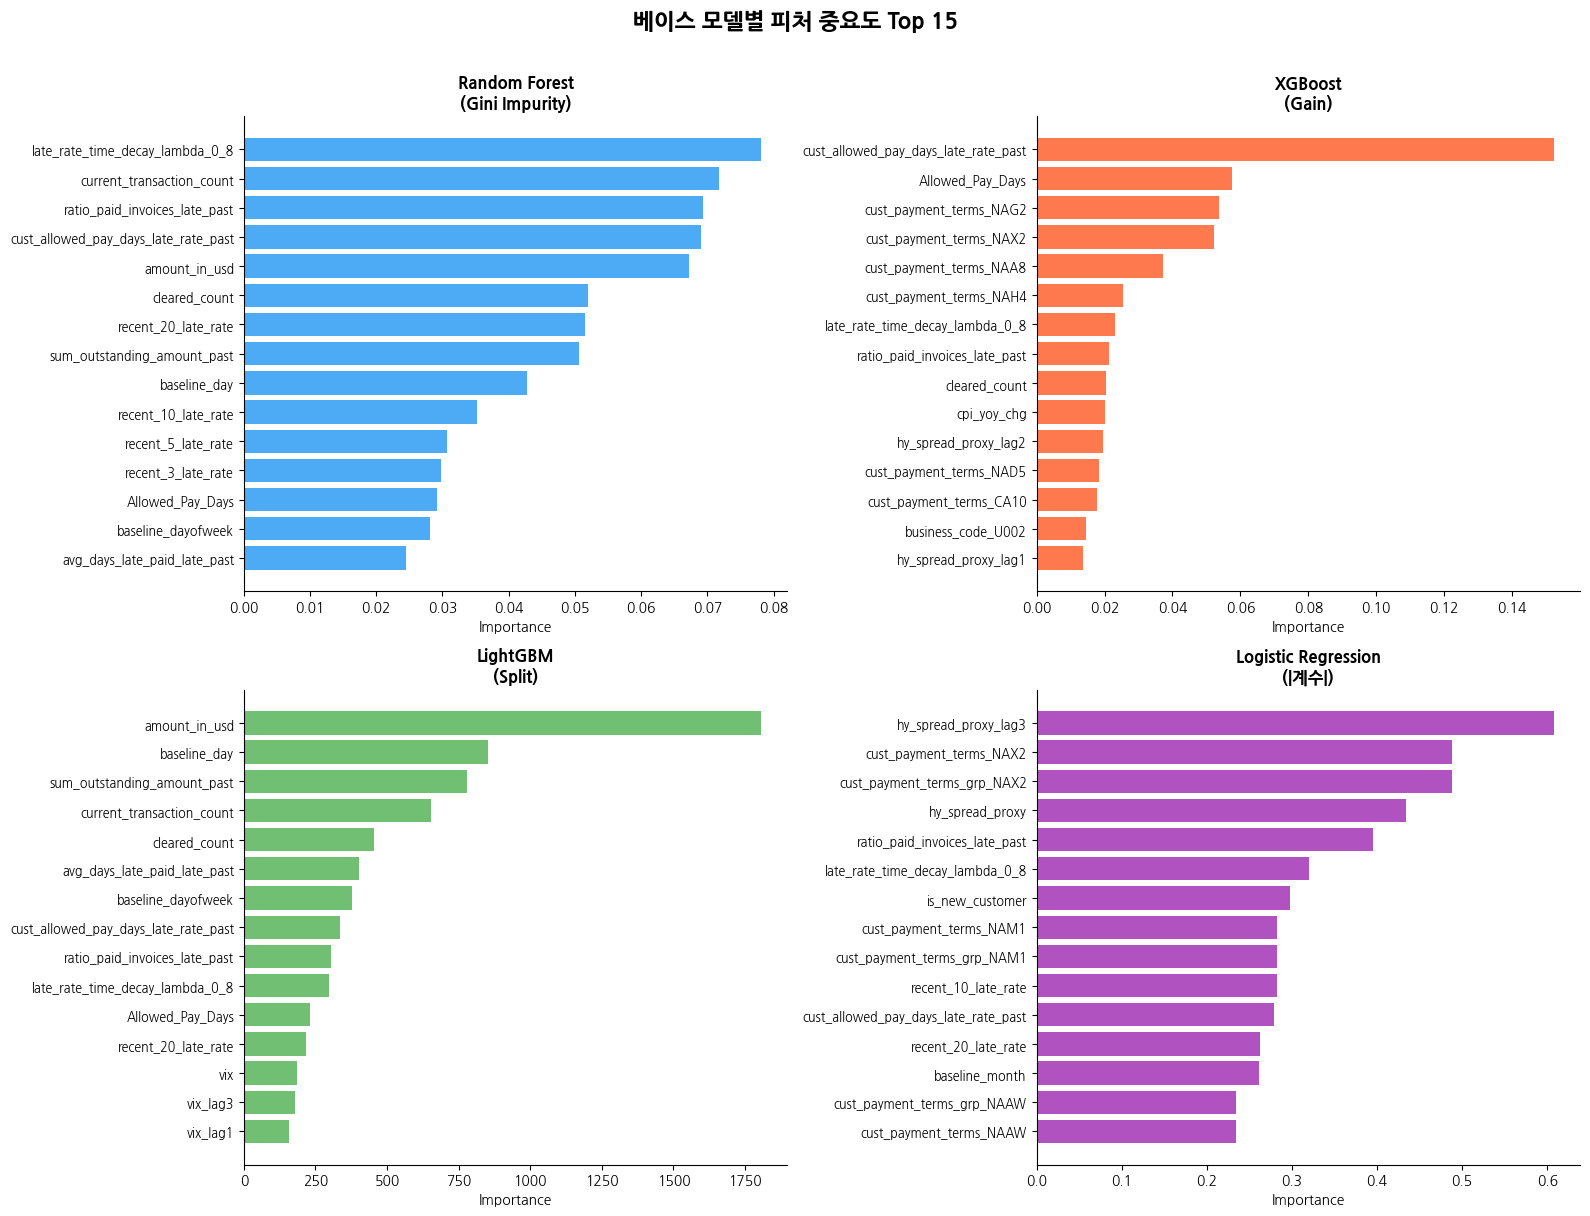

저장: feature_importance_by_model.png


In [96]:
TOP_N = 15

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('베이스 모델별 피처 중요도 Top 15', fontsize=16, fontweight='bold', y=1.01)

plot_data = [
    ("Random Forest\n(Gini Impurity)", rf_importance, "#2196F3"),
    ("XGBoost\n(Gain)", xgb_importance, "#FF5722"),
    ("LightGBM\n(Split)", lgbm_importance, "#4CAF50"),
    ("Logistic Regression\n(|계수|)", lr_importance, "#9C27B0"),
]

for ax, (title, importance, color) in zip(axes.flatten(), plot_data):
    top = importance.head(TOP_N)
    ax.barh(range(TOP_N), top.values[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top.index[::-1], fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance")
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance_by_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: feature_importance_by_model.png")

메타 모델 계수 (양수=연체 기여, 음수=정상 기여)
  LR (로지스틱 회귀)              +2.7534  ▲ 연체 기여
  RF (랜덤 포레스트)              +3.6194  ▲ 연체 기여
  XGB (XGBoost)             +0.3669  ▲ 연체 기여
  LGBM (LightGBM)           +1.1339  ▲ 연체 기여


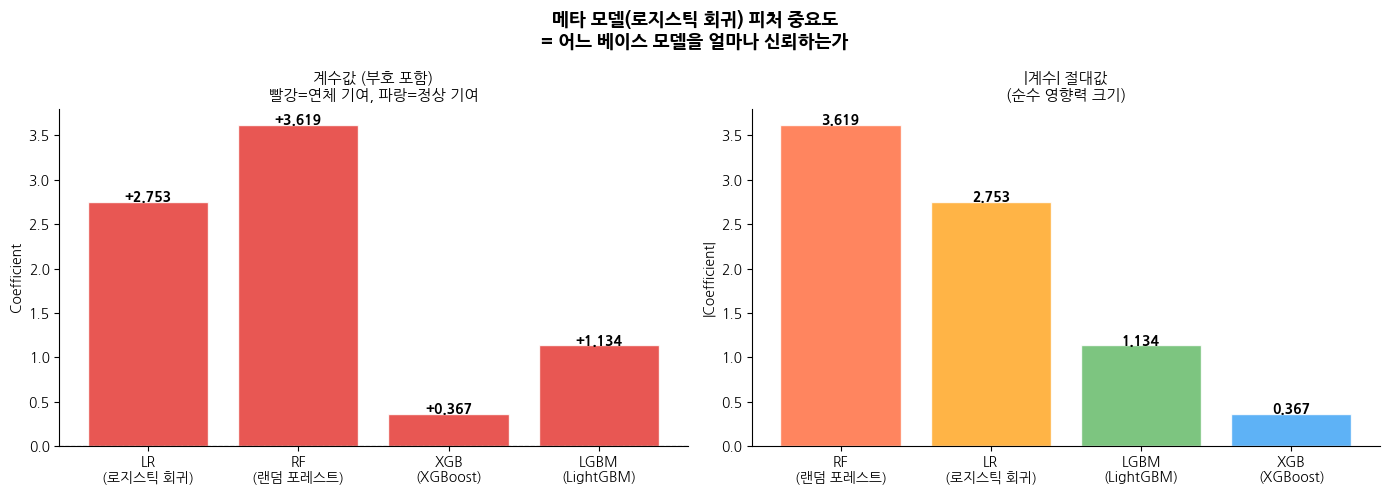

저장: meta_model_feature_importance.png


In [97]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 메타 모델 계수 추출
# meta_model의 입력: [LR_prob, RF_prob, XGB_prob, LGBM_prob]
meta_feature_names = ['LR\n(로지스틱 회귀)', 'RF\n(랜덤 포레스트)', 'XGB\n(XGBoost)', 'LGBM\n(LightGBM)']
meta_coef = meta_model.coef_[0]  # shape: (4,)

meta_importance = pd.Series(meta_coef, index=meta_feature_names)
meta_importance_sorted = meta_importance.abs().sort_values(ascending=False)

print("=" * 45)
print("메타 모델 계수 (양수=연체 기여, 음수=정상 기여)")
print("=" * 45)
for name, coef in zip(meta_feature_names, meta_coef):
    direction = "▲ 연체 기여" if coef > 0 else "▼ 정상 기여"
    print(f"  {name.replace(chr(10), ' '):<25} {coef:+.4f}  {direction}")

# ── 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('메타 모델(로지스틱 회귀) 피처 중요도\n= 어느 베이스 모델을 얼마나 신뢰하는가', 
             fontsize=13, fontweight='bold')

# 왼쪽: 원래 계수값 (부호 포함 → 방향성 파악)
colors = ['#E53935' if c > 0 else '#1E88E5' for c in meta_coef]
axes[0].bar(meta_feature_names, meta_coef, color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('계수값 (부호 포함)\n빨강=연체 기여, 파랑=정상 기여', fontsize=11)
axes[0].set_ylabel('Coefficient')
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(meta_coef):
    axes[0].text(i, v + 0.01 * np.sign(v), f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')

# 오른쪽: 절대값 (순수 영향력 크기)
imp_sorted_idx = np.argsort(np.abs(meta_coef))[::-1]
sorted_names = [meta_feature_names[i] for i in imp_sorted_idx]
sorted_abs   = np.abs(meta_coef)[imp_sorted_idx]
bar_colors   = ['#FF7043', '#FFA726', '#66BB6A', '#42A5F5']

axes[1].bar(sorted_names, sorted_abs, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_title('|계수| 절대값\n(순수 영향력 크기)', fontsize=11)
axes[1].set_ylabel('|Coefficient|')
axes[1].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(sorted_abs):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('meta_model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: meta_model_feature_importance.png")

In [105]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, f1_score

# 최종 예측 확률 (앞서 구한 final_pred_prob 사용)
thresholds = np.arange(0.1, 0.9, 0.01)

results = []
for t in thresholds:
    pred_t = (final_pred_prob >= t).astype(int)
    results.append({
        'threshold' : round(t, 2),
        'accuracy'  : accuracy_score(test_y, pred_t),
        'macro_f1'  : f1_score(test_y, pred_t, average='macro'),
        'f1_class1' : f1_score(test_y, pred_t, pos_label=1, average='binary')
        
    })

threshold_df = pd.DataFrame(results)

# 목적에 따라 기준 선택
best_macro_f1  = threshold_df.loc[threshold_df['macro_f1'].idxmax()]
best_f1_class1 = threshold_df.loc[threshold_df['f1_class1'].idxmax()]

print("[ macro F1 최대 임계치 ]")
print(best_macro_f1.to_string())
print("\n[ 연체(class=1) F1 최대 임계치 ]")
print(best_f1_class1.to_string())

[ macro F1 최대 임계치 ]
threshold    0.310000
accuracy     0.959375
macro_f1     0.771810
f1_class1    0.564926

[ 연체(class=1) F1 최대 임계치 ]
threshold    0.260000
accuracy     0.957875
macro_f1     0.771513
f1_class1    0.565161


In [111]:
meta_model.coef_

array([[2.7534161 , 3.61938099, 0.36689871, 1.13389331]])